In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset Shape:", df.shape)
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())

for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after cleaning:")
print(df.isnull().sum())

Dataset Shape: (4000, 28)
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Di

In [2]:
season_summary = df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3"
]].mean()

print(season_summary.round(2))

        Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Profit_INR  \
Season                                                                
Kharif             5.63              46.31    710719.06   178914.65   
Rabi               5.04              41.49    601526.05    87689.47   
Zaid               4.64              38.89    519171.90   -24804.82   

        Water_Used_m3  
Season                 
Kharif        6102.20  
Rabi          5846.99  
Zaid          6419.89  


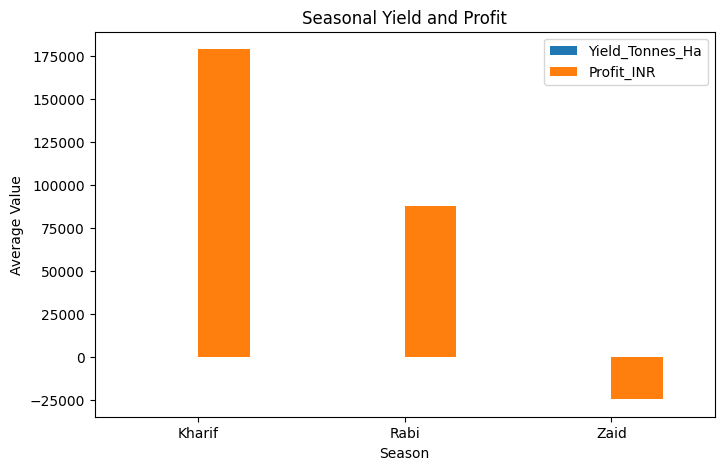

In [3]:
summary = df.groupby("Season")[[
    "Yield_Tonnes_Ha",
    "Profit_INR"
]].mean()

summary.plot(kind="bar", figsize=(8,5))

plt.title("Seasonal Yield and Profit")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

        Rainfall_mm  Avg_Temperature_C  Disease_Pest_Risk_pct
Season                                                       
Kharif       849.20              28.45                  54.47
Rabi         437.62              23.49                  40.48
Zaid         304.65              31.04                  38.22


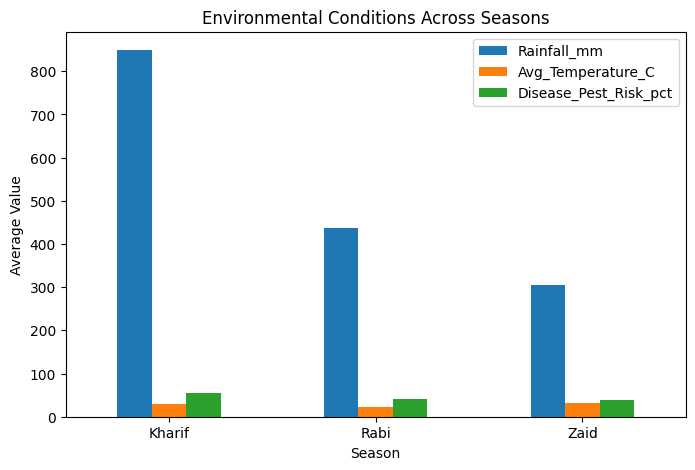

In [4]:
environment = df.groupby("Season")[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Disease_Pest_Risk_pct"
]].mean()

print(environment.round(2))

environment.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Environmental Conditions Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

           Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Profit_INR
Crop                                                                  
Chilli                1.54              12.38   1276777.23   750878.34
Cotton                1.23               9.40    639423.08   124546.92
Groundnut             1.32               9.66    542935.50    44858.12
Maize                 2.71              21.78    457067.99   -83978.33
Pulses                0.92               7.40    528465.87    -4238.05
Rice                  2.43              19.29    423615.26  -102213.50
Sugarcane            46.64             392.41   1371980.11   817187.99
Wheat                 2.11              16.85    400104.89  -123398.34


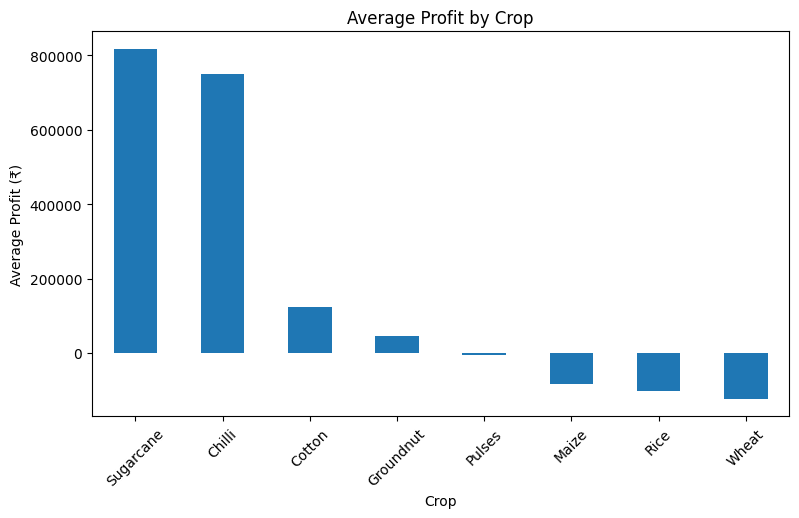

In [5]:
crop_analysis = df.groupby("Crop")[[
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Profit_INR"
]].mean()

print(crop_analysis.round(2))

crop_analysis["Profit_INR"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (₹)")
plt.xticks(rotation=45)
plt.show()

In [6]:
correlation = df.select_dtypes(
    include=np.number
).corr()["Profit_INR"].sort_values(
    ascending=False
)

print("Correlation with Profit:")
print(correlation)

Correlation with Profit:
Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488466
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.107648
Soil_Moisture_pct                0.091281
Nitrogen_kg_ha                   0.085016
Total_Cost_INR                   0.068356
Disease_Pest_Risk_pct            0.067583
Humidity_pct                     0.063775
Phosphorus_kg_ha                 0.049747
Potassium_kg_ha                  0.031192
Seed_Quality_Score               0.010438
Avg_Temperature_C                0.009043
Soil_pH                         -0.013145
Pesticide_Litre_ha              -0.025705
Sunlight_Hours_Day              -0.054822
Fertilizer_kg_ha                -0.073542
Name: Profit_INR, dtype: float64


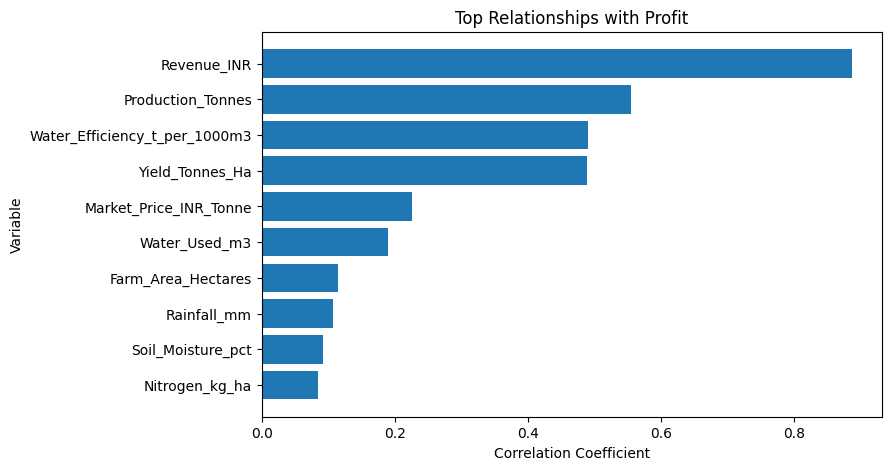

In [7]:
corr_plot = correlation.drop(
    "Profit_INR"
).head(10).sort_values()

plt.figure(figsize=(8,5))

plt.barh(
    corr_plot.index,
    corr_plot.values
)

plt.xlabel("Correlation Coefficient")
plt.ylabel("Variable")
plt.title("Top Relationships with Profit")

plt.axvline(0)
plt.show()